In [1]:
rm -rf __pycache__/

[*********************100%***********************]  1 of 1 completed


2024-12-31, Strategy initialized.
2015-07-09, RSI: 28.11, Position: 0
2015-07-09, Placing BUY for size: 2998 (retry 0)
2015-07-09, 📈 BUY SIGNAL placed with size 2998
2015-07-10, BUY EXECUTED at 30.49 for 2998 units
2015-07-10, RSI: 41.13, Position: 2998
2015-07-13, RSI: 48.57, Position: 2998
2015-07-14, RSI: 48.43, Position: 2998
2015-07-15, RSI: 52.00, Position: 2998
2015-07-15, 🔁 CLOSING LONG: RSI crossed above 50
2015-07-16, SELL EXECUTED at 31.93 for -2998 units
2015-07-16, ⚠️ Contract fallback used: 1
2015-07-16, 📦 TRADE LOGGED: contracts=1, pnl=4347.096569061279
2015-07-16, RSI: 56.52, Position: 0
2015-07-17, RSI: 59.24, Position: 0
2015-07-20, RSI: 64.51, Position: 0
2015-07-21, RSI: 60.01, Position: 0
2015-07-22, RSI: 45.64, Position: 0
2015-07-23, RSI: 45.51, Position: 0
2015-07-24, RSI: 44.05, Position: 0
2015-07-27, RSI: 40.40, Position: 0
2015-07-28, RSI: 42.22, Position: 0
2015-07-29, RSI: 41.35, Position: 0
2015-07-30, RSI: 39.95, Position: 0
2015-07-31, RSI: 37.57, Posit

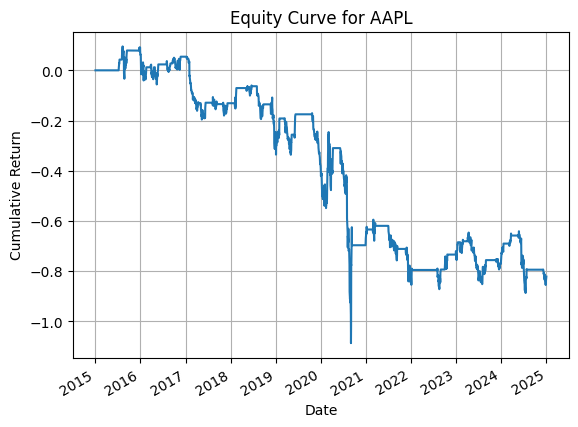


✅ Report saved to:
- CSV: aapl_rsi_metrics.csv
- PDF: aapl_rsi_report.pdf


/Users/siddharthbhattacharya/Quant_Research_Lab/utils/report.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2%}" for y in ax.get_yticks()])


In [2]:
# Cell 1: Setup
import sys
sys.path.append("..")

# Cell 2: Imports
from utils.data_loader import load_data
from strategies.rsi_mean_reversion import RSIMeanReversion
from backtest_engine.runner import BacktestRunner
from utils.report import StrategyReport
import matplotlib.pyplot as plt

# Cell 3: Load data
symbol = "AAPL"
df = load_data(symbol, start="2015-01-01", end="2025-01-01")

# Cell 4: Run backtest
runner = BacktestRunner(cash=100_000)

# Run strategy and store instance explicitly
metrics, returns, trade_stats, strategy = runner.run(
    RSIMeanReversion,
    df,
    rsi_period=14,
    rsi_lower=30,
    rsi_upper=70,
    return_trades=True,
    return_strategy=True,
    debug=True,
    log_file="aapl_rsi_strategy_logs.txt"
)

# Cell 5: Print performance metrics
print("📊 Strategy Metrics\n" + "-"*35)
for m, v in metrics.iloc[0].items():
    print(f"{m.replace('_', ' ').title():<30}: {v:.4f}")

# Cell 6: Plot equity curve
returns.cumsum().plot(title=f"Equity Curve for {symbol}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

# Cell 7: Generate report explicitly using logged trades
csv_path = f"{symbol.lower()}_rsi_metrics.csv"
pdf_path = f"{symbol.lower()}_rsi_report.pdf"

# Pass explicitly logged trades from strategy instance
report = StrategyReport(returns, trades=strategy.trades, risk_free_rate=0.0)
report.run_all(csv_path, pdf_path)

print(f"\n✅ Report saved to:\n- CSV: {csv_path}\n- PDF: {pdf_path}")